# 02. Setting A — 일별 21일 누적 수익률 예측 (GRU)

**Phase 1 — Step 2: GRU × ETF × 일별(21영업일 뒤) 설정**

## 이 노트북의 역할

| 절 | 내용 | 상태 |
|---|---|---|
| §1 | 환경 설정 로드 (`%run 00`) | ✅ |
| §2 | 데이터 로드 (SPY·QQQ CSV) | ✅ |
| §3 | 타깃 생성 (21일 누적 forward log-return) | ✅ |
| §4 | 누수 검증 (assert + 육안 표) | ✅ |
| §5 | SequenceDataset · make_sequences 파라미터 검증 | ✅ |
| §6 | Walk-Forward fold 생성 (231/21/21/21/21) | ✅ |
| §7 | GRURegressor import + smoke test | ✅ |
| §8 | 학습 루프 (106 fold × SPY·QQQ) | 실행 필요 |
| §9 | 평가·시각화 (관문 판정 + 8종 진단 플롯) | 실행 필요 |
| §10 | 결론·체크포인트 | 실행 필요 |

## Phase 1 관문

- **Hit Rate > 0.55** AND **R²_OOS > 0** 둘 다 충족 시 PASS → Phase 2 진행
- LSTM 과의 공정 비교: 동일 데이터·파라미터·Walk-Forward 설정 사용

## GRU vs LSTM 비교 배경

Phase1_LSTM 결과분석5.md §6 Option C:
> GRU는 LSTM 대비 파라미터 수 약 25% 감소 → 134샘플 환경에서 오히려 안정적일 수 있음.

GRU 게이트 구조 (LSTM과 차이):
- LSTM: input gate, forget gate, output gate, cell state → 4×H² 파라미터
- GRU: reset gate, update gate → 3×H² 파라미터 (cell state 없음)
- 결과적으로 같은 hidden_size 에서 GRU 파라미터 수 ≈ LSTM × 0.75

## §1. 환경 설정 로드

**무엇을**: `00_setup_and_utils.ipynb` 의 공통 설정을 한 줄로 로드한다.

**왜 이 방식**: 한글 폰트·시드·경로 상수(`RAW_DATA_DIR`, `RESULTS_DIR` 등)를
매 노트북 시작마다 반복 작성하지 않고, `%run` 으로 호출해 DRY 원칙을 지킨다.

**주의**: 이 노트북은 반드시 `Phase1_GRU/` 디렉토리에서 실행해야 한다.
`scripts/` 패키지 import 경로가 cwd 기반이므로 다른 위치에서 실행하면 ImportError 발생.

In [1]:
%run ./00_setup_and_utils.ipynb

[OK] scripts.setup import 완료 — BASE_DIR = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU
[OK] 한글 폰트 설정 완료: AppleGothic
[OK] 시드 고정 완료: SEED=42
[정보] PyTorch 버전: 2.11.0, CUDA 가용: False
[OK] 경로 상수 확인
  BASE_DIR      = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU
  RAW_DATA_DIR  = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/raw_data
  SETTING_A_DIR = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A
  SETTING_B_DIR = /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_B
[OK] 공통 import + 표시 옵션 적용 완료
  pandas 2.3.3, numpy 2.4.4
  Phase 1 — GRU 단독 베이스라인 / 환경 설정 완료
  한글 폰트  : AppleGothic
  시드       : 42
  결과 경로  : /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results
  진실원     : scripts/setup.py


## §2. 데이터 로드

**무엇을**: `01_data_download_and_eda.ipynb` 가 저장한 SPY·QQQ CSV를 읽고
분석 기간(2016-01-01 ~ 2025-12-31)으로 절단한다.

**데이터 위치**: Phase1_LSTM 의 `results/raw_data/` 를 공유 사용. 재다운로드 불필요.

**왜 분석 기간 절단**: 2009~2015 구간은 lookback 채움용 워밍업으로만 사용한다.
Scaler fit 및 Walk-Forward fold 생성은 2016~2025 구간만 대상으로 한다 (누수 방지).

**Adj Close vs Close**: 배당·주식분할이 반영된 Adj Close 사용. log-return 계산 기준.

In [2]:
ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'

# Phase1_LSTM 의 raw_data 공유 사용 (재다운로드 불필요)
LSTM_RAW_DATA_DIR = BASE_DIR.parent / 'Phase1_LSTM' / 'results' / 'raw_data'

raw_dict = {}
for tic in ['SPY', 'QQQ']:
    df = pd.read_csv(LSTM_RAW_DATA_DIR / f'{tic}.csv', index_col=0, parse_dates=True)
    df['log_return'] = np.log(df['Adj Close']).diff()  # 누수: 전체 기간에서 diff → 시작일 NaN 방지
    raw_dict[tic] = df.loc[ANALYSIS_START:ANALYSIS_END]

print(f'{"티커":>6}  {"행수":>6}  {"NaN":>4}  {"시작일":>12}  {"종료일":>12}')
print('-' * 55)
for tic, df in raw_dict.items():
    lr = df['log_return']
    print(f'{tic:>6}  {len(df):>6}  {lr.isna().sum():>4}  '
          f'{str(df.index[0].date()):>12}  {str(df.index[-1].date()):>12}')

    티커      행수   NaN           시작일           종료일
-------------------------------------------------------
   SPY    2514     0    2016-01-04    2025-12-31
   QQQ    2514     0    2016-01-04    2025-12-31


## §3. 타깃 생성 — 21일 누적 forward log-return

**무엇을**: Setting A 의 예측 대상인 **21영업일 후 누적 log-return** 을 생성한다.

**왜 21일**: 미국 시장 영업월(≈ 1개월)의 표준 거래일 수. 월별 리밸런싱 시나리오에 대응.

**공식**:
```
log_ret[t]  = log(close[t]) - log(close[t-1])
target[t]   = log_ret[t+1] + ... + log_ret[t+21]   ← t 시점에서 보는 미래 21일 합
            = log_ret.rolling(21).sum().shift(-21)[t]
```

**누수 방지**: shift(-21) 이 미래 참조처럼 보이지만, 이것이 예측 목표 자체이다.
모델 입력은 반드시 t 이전 데이터여야 하며, 이는 §6 Walk-Forward Purge+Embargo 로 보장.

In [3]:
from scripts.targets import build_daily_target_21d

targets_dict = {}
for tic, df in raw_dict.items():
    target = build_daily_target_21d(df['Adj Close'])  # 누수: rolling(21).sum().shift(-21)
    targets_dict[tic] = target
    n_nan = target.isna().sum()
    print(f'[{tic}] target shape={target.shape}, NaN={n_nan} '
          f'(첫1행 diff + 마지막21행 forward 부족)')

[SPY] target shape=(2514,), NaN=21 (첫1행 diff + 마지막21행 forward 부족)
[QQQ] target shape=(2514,), NaN=21 (첫1행 diff + 마지막21행 forward 부족)


## §4. 누수 검증 — 2종 체크포인트

**무엇을**: 타깃 시계열이 미래 데이터를 *의도치 않게* 입력에 흘리지 않음을 확인한다.

**검증 1 (Assert)**: 3개 무작위 시점 t 에서 `target[t] == log_ret[t+1:t+22].sum()` assert.

**검증 2 (육안 표)**: 첫 5개 유효 행의 (날짜, log_ret, target, 직접계산, 일치 O/X) 출력.

**실패 시**: AssertionError 발생 → 타깃 생성 코드 즉시 재검토.

In [4]:
# 검증 1·2 — assert 단위 테스트 + 육안 확인 표
from scripts.targets import verify_no_leakage

for tic, df in raw_dict.items():
    print(f'\n=== [{tic}] 누수 검증 ===')
    log_ret_valid = df['log_return'].dropna()
    verify_no_leakage(log_ret_valid, targets_dict[tic], n_checks=3, seed=42)


=== [SPY] 누수 검증 ===
=== 누수 검증 1 — Assert 단위 테스트 ===
  [PASS] 2016-11-17  target=0.035304  직접계산=0.035304  Δ=0.00e+00
  [PASS] 2022-06-27  target=0.031536  직접계산=0.031536  Δ=0.00e+00
  [PASS] 2023-08-31  target=-0.048994  직접계산=-0.048994  Δ=0.00e+00

=== 누수 검증 2 — 육안 확인 표 (첫 5개 유효 행) ===
            날짜     log_ret      target        직접계산    일치
  ------------------------------------------------------
    2016-01-04   -0.014078   -0.049561   -0.049561     O
    2016-01-05    0.001690   -0.049685   -0.049685     O
    2016-01-06   -0.012695   -0.056224   -0.056224     O
    2016-01-07   -0.024284   -0.045492   -0.045492     O
    2016-01-08   -0.011037   -0.034401   -0.034401     O

[OK] 누수 검증 완료 — 모든 체크포인트 PASS

=== [QQQ] 누수 검증 ===
=== 누수 검증 1 — Assert 단위 테스트 ===
  [PASS] 2016-11-17  target=0.022546  직접계산=0.022546  Δ=0.00e+00
  [PASS] 2022-06-27  target=0.047935  직접계산=0.047935  Δ=0.00e+00
  [PASS] 2023-08-31  target=-0.043823  직접계산=-0.043823  Δ=0.00e+00

=== 누수 검증 2 — 육안 확인 표 (첫 5개 유효 행) ==

## §5. `SequenceDataset` · `make_sequences` — Setting A 파라미터 검증

**무엇을**: `scripts/dataset.py` 의 공개 인터페이스를 로드하고 Setting A 파라미터로
슬라이딩 윈도우 형태를 검증한다.

**GRU 입력 형태**: `(B, T, F)` — batch_first=True 기준. LSTM 과 동일.

**Setting A 파라미터**:
- `SEQ_LEN = 63` (약 3개월 lookback, 2026-04-25 수정: 126 → 63)
- `IS = 231`, `PURGE = EMB = OOS = STEP = 21`
- N_train = IS − seq_len = 231 − 63 = 168 (LSTM 의 134 보다 많음)

In [5]:
from scripts.dataset import (
    SequenceDataset,
    make_sequences,
    walk_forward_folds,
    build_fold_datasets,
)
from torch.utils.data import DataLoader

print('[OK] scripts.dataset import 완료')

[OK] scripts.dataset import 완료


In [6]:
# Setting A 파라미터
SEQ_LEN = 63   # 약 3개월 lookback

spy_lr  = raw_dict['SPY']['log_return'].values   # shape (2514,)
qqq_lr  = raw_dict['QQQ']['log_return'].values
spy_tgt = targets_dict['SPY'].values             # shape (2514,), 마지막 21행 NaN

# make_sequences 로 X 형태 확인
X_spy, _ = make_sequences(spy_lr, seq_len=SEQ_LEN)

print(f'make_sequences(spy_lr, seq_len={SEQ_LEN}) 결과')
print(f'  X.shape = {X_spy.shape}   → (N, seq_len={SEQ_LEN}, n_features=1)')
print()
print(f'Setting A 폴드별 훈련 샘플 수 (IS=231, seq_len=63):')
print(f'  N_train = IS − seq_len = 231 − 63 = {231 - SEQ_LEN}')
print(f'  N_test  = OOS = 21')

make_sequences(spy_lr, seq_len=63) 결과
  X.shape = (2451, 63, 1)   → (N, seq_len=63, n_features=1)

Setting A 폴드별 훈련 샘플 수 (IS=231, seq_len=63):
  N_train = IS − seq_len = 231 − 63 = 168
  N_test  = OOS = 21


## §6. Walk-Forward fold 생성

**무엇을**: Setting A 의 Walk-Forward 교차검증 폴드 인덱스를 생성하고 검증한다.

**왜 Walk-Forward + Purge + Embargo** (López de Prado 2018):
- **Purge(21)**: 타깃이 t+1~t+21 미래를 참조 → IS 마지막 21일 제거
- **Embargo(21)**: autocorrelation 잔존이 OOS 첫 구간 성능을 부풀리는 것 방지
- 금융 시계열 walk-forward 누수 방지의 사실상 학술 표준

```
날짜 축 →
Fold 1: ├── IS (231일) ──┤ purge(21) │ emb(21) │ OOS(21) ┤
Fold 2: (21일 오른쪽 이동) ├── IS (231일) ──┤ ...
... (약 105~106개 fold, 10년치)
```

In [7]:
IS, PURGE, EMB, OOS, STEP = 231, 21, 21, 21, 21

# 타깃 마지막 21행 NaN → fold 생성 기준은 유효 타깃 수로 통일 (누수 방지)
spy_n_valid = int(targets_dict['SPY'].notna().sum())
qqq_n_valid = int(targets_dict['QQQ'].notna().sum())
n_samples = min(spy_n_valid, qqq_n_valid)
print(f'SPY 유효 타깃 수: {spy_n_valid}  /  QQQ 유효 타깃 수: {qqq_n_valid}  /  fold 생성 n: {n_samples}')

folds = walk_forward_folds(n_samples, IS, PURGE, EMB, OOS, STEP)
print(f'총 폴드 수: {len(folds)}')

dates = raw_dict['SPY'].index
print(f'{"폴드":>4}  {"train 시작":>12}  {"train 끝":>12}  {"test 시작":>12}  {"test 끝":>12}')
print('-' * 65)
for fold_i in [0, 1, 2, len(folds) - 1]:
    tr, te = folds[fold_i]
    print(f'{fold_i:>4}  {str(dates[tr[0]].date()):>12}  {str(dates[tr[-1]].date()):>12}  '
          f'{str(dates[te[0]].date()):>12}  {str(dates[te[-1]].date()):>12}')

SPY 유효 타깃 수: 2493  /  QQQ 유효 타깃 수: 2493  /  fold 생성 n: 2493
총 폴드 수: 105
  폴드      train 시작       train 끝       test 시작        test 끝
-----------------------------------------------------------------
   0    2016-01-04    2016-11-30    2017-02-02    2017-03-03
   1    2016-02-03    2016-12-30    2017-03-06    2017-04-03
   2    2016-03-04    2017-02-01    2017-04-04    2017-05-03
 104    2024-09-09    2025-08-11    2025-10-10    2025-11-07


In [8]:
# 폴드 0 — build_fold_datasets 로 텐서 생성 검증
train_idx_0, test_idx_0 = folds[0]

train_ds, test_ds, scaler = build_fold_datasets(
    spy_lr, train_idx_0, test_idx_0, SEQ_LEN,
    target_series=spy_tgt,
)

print('=== 폴드 0 텐서 형태 (Setting A: seq_len=63, target=21일 누적) ===')
print(f'train_ds.X : {tuple(train_ds.X.shape)}   (N_train, seq_len, n_feat)')
print(f'train_ds.y : {tuple(train_ds.y.shape)}')
print(f'test_ds.X  : {tuple(test_ds.X.shape)}    (N_test, seq_len, n_feat)')
print(f'test_ds.y  : {tuple(test_ds.y.shape)}')
print()
print(f'[타깃 통계 — 비정규화 (21일 누적 수익률)]')
print(f'  train y mean  = {train_ds.y.mean().item():.6f}')
print(f'  train y std   = {train_ds.y.std().item():.6f}')

=== 폴드 0 텐서 형태 (Setting A: seq_len=63, target=21일 누적) ===
train_ds.X : (168, 63, 1)   (N_train, seq_len, n_feat)
train_ds.y : (168,)
test_ds.X  : (21, 63, 1)    (N_test, seq_len, n_feat)
test_ds.y  : (21,)

[타깃 통계 — 비정규화 (21일 누적 수익률)]
  train y mean  = 0.011501
  train y std   = 0.022926


In [9]:
# DataLoader 배치 검증
# shuffle=True  → 훈련 시 시간 순서 무작위화 (순서 무관성 확보)
# shuffle=False → 테스트 시 시간 순서 보존
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=len(test_ds), shuffle=False)

print(f'train_loader: {len(train_loader)} 배치 (batch_size={BATCH_SIZE}, N={len(train_ds)})')
print(f'test_loader : {len(test_loader)} 배치  (전체 한 번에)')

for xb, yb in train_loader:
    print(f'[train 첫 배치] X: {tuple(xb.shape)},  y: {tuple(yb.shape)},  dtype: {xb.dtype}')
    break

train_loader: 6 배치 (batch_size=32, N=168)
test_loader : 1 배치  (전체 한 번에)
[train 첫 배치] X: (32, 63, 1),  y: (32,),  dtype: torch.float32


## §7. GRURegressor import — Setting A 사양

**무엇을**: `scripts/models.py` 의 `GRURegressor` 를 로드하고 Setting A 파라미터로 초기화.

**GRU vs LSTM 파라미터 비교** (hidden=32, input=1):
- LSTM(num_layers=1): 4×(32×1 + 32×32 + 32) ≈ 4,352 params
- GRU(num_layers=1):  3×(32×1 + 32×32 + 32) ≈ 3,264 params  (약 25% 감소)
- LSTM(hidden=32) 과 동일 하이퍼파라미터 → 공정 비교

**batch_first=True 필수**: DataLoader 출력 `(B, T, F)` 와 일치.

In [10]:
# ===== §7 GRURegressor — 설정 A 사양 =====
from scripts.models import GRURegressor, count_parameters

# 설정 A: LSTM 과 동일 파라미터 (공정 비교)
# num_layers=1 → GRU 자체 dropout 무효 → models.py 가 head_dropout 으로 자동 우회
model = GRURegressor(
    input_size=1,
    hidden_size=32,
    num_layers=1,
    dropout=0.3,
    batch_first=True,
)
print(model)
print(f'\n학습 가능 파라미터 수: {count_parameters(model):,}')

# Forward shape 검증: (32, 63, 1) → (32,)
with torch.no_grad():
    _x_smoke = torch.randn(32, SEQ_LEN, 1)
    _y_smoke = model(_x_smoke)
print(f'smoke test : input {tuple(_x_smoke.shape)} → output {tuple(_y_smoke.shape)}  '
      + ('[PASS]' if _y_smoke.shape == torch.Size([32]) else '[FAIL]'))

GRURegressor(
  (gru): GRU(1, 32, batch_first=True)
  (head_dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

학습 가능 파라미터 수: 3,393
smoke test : input (32, 63, 1) → output (32,)  [PASS]


## §8. 학습 루프 — Walk-Forward 전체 fold

**무엇을**: 105~106 fold 전체에 대해 GRU 학습·예측 수집 (train/val/test 모두).

**실행 시간**: CPU 기준 약 10~30분 / GPU 기준 2~5분.

**학습 하이퍼파라미터** (LSTM 3차 Run 기준, 공정 비교):
- hidden=32, num_layers=1, dropout=0.3, seq_len=63
- max_epochs=30, patience=5, lr=1e-3, weight_decay=1e-3
- Loss: HuberLoss(delta=0.01), Optimizer: AdamW

**fold 모델 저장 정책**: 재현성은 (a) seed 고정 + (b) fold 별 y_true/y_pred 를 metrics.json 에
보관하여 확보. fold 모델 state_dict 는 일회용으로 메모리에서 해제.

**1순위 A (과적합 진단)**: fold 별 train/val/test 예측을 모두 수집해 §9.F 과적합 갭 분석.

In [11]:
# ===== §8 학습 루프 — fold × SPY·QQQ =====
import time
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader

from scripts.train import train_one_fold, get_device
from scripts.setup import SETTING_A_DIR

# 학습 하이퍼파라미터 상수
HIDDEN       = 32
NUM_LAYERS   = 1
DROPOUT      = 0.3
MAX_EPOCHS   = 30
PATIENCE     = 5
LR_PATIENCE  = 3
LR           = 1e-3
WEIGHT_DECAY = 1e-3
INPUT_SIZE   = 1      # univariate (log_return 단일 채널)

VAL_RATIO = 0.2


def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=32):
    """IS 훈련 세트를 시간순 80/20 로 재분할하여 train·val DataLoader 생성."""
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def _split_train_val_indices(n_is, val_ratio=VAL_RATIO):
    n_val = max(1, int(n_is * val_ratio))
    n_tr = n_is - n_val
    return n_tr, n_val


def run_all_folds(
    ticker, series, target, folds, seq_len,
    extra_features=None,
    input_size=1,
    hidden=32, num_layers=1, dropout=0.3,
    max_epochs=30, patience=5, lr=1e-3, weight_decay=1e-3,
    lr_patience=3,
    log_every=20, device=None,
):
    """ticker 1개에 대해 전체 fold GRU 학습·예측 수집 (train/val/test 모두)."""
    device = get_device('auto') if device is None else torch.device(device)
    print(f'  device: {device}')
    fold_out = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series, tr_idx, te_idx, seq_len,
            target_series=target,
            extra_features=extra_features,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k, val_ratio=VAL_RATIO)

        # 폴드별 GRU 모델 — 매번 새로 초기화 (fold 독립성 보장)
        model_k = GRURegressor(
            input_size=input_size, hidden_size=hidden, num_layers=num_layers,
            dropout=dropout, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=max_epochs, early_stop_patience=patience,
            lr=lr, weight_decay=weight_decay,
            lr_patience=lr_patience,
            device=device, verbose=False,
        )

        # best 모델로 train/val/test 모두 예측
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred_oos = model_k(te_ds_k.X.to(device)).cpu().numpy()
            y_pred_is  = model_k(tr_ds_k.X.to(device)).cpu().numpy()

        y_true_oos = te_ds_k.y.numpy()
        y_true_is  = tr_ds_k.y.numpy()

        n_tr, n_val = _split_train_val_indices(len(tr_ds_k), val_ratio=VAL_RATIO)
        y_true_train = y_true_is[:n_tr]
        y_pred_train = y_pred_is[:n_tr]
        y_true_val   = y_true_is[n_tr:]
        y_pred_val   = y_pred_is[n_tr:]

        fold_out.append({
            'k': k,
            'y_true': y_true_oos,
            'y_pred': y_pred_oos,
            'y_true_train': y_true_train,
            'y_pred_train': y_pred_train,
            'y_true_val':   y_true_val,
            'y_pred_val':   y_pred_val,
            'best_val_loss': result['best_val_loss'],
            'best_epoch':    result['best_epoch'],
            'stopped_early': result['stopped_early'],
            'history':       result['history'],
        })

        if device.type == 'cuda':
            del model_k
            torch.cuda.empty_cache()

        if (k + 1) % log_every == 0 or k == 0 or k == len(folds) - 1:
            elapsed = time.time() - t_start
            print(f'  [{ticker}] fold {k+1:3d}/{len(folds)}  '
                  f'best_ep={result["best_epoch"]:3d}  '
                  f'val={result["best_val_loss"]:.6f}  '
                  f'early={result["stopped_early"]}  '
                  f'({elapsed:.1f}s 경과)')
    return fold_out


# SPY · QQQ 전체 학습
ALL_RESULTS = {}
_total_start = time.time()
for ticker in ['SPY', 'QQQ']:
    print(f'\n{"="*60}\n  [{ticker}] {len(folds)} fold GRU 학습 시작\n{"="*60}')
    series_arr = raw_dict[ticker]['log_return'].values
    target_arr = targets_dict[ticker].values

    (SETTING_A_DIR / ticker).mkdir(parents=True, exist_ok=True)
    ALL_RESULTS[ticker] = run_all_folds(
        ticker, series_arr, target_arr, folds, SEQ_LEN,
        input_size=INPUT_SIZE,
        hidden=HIDDEN, num_layers=NUM_LAYERS, dropout=DROPOUT,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, lr_patience=LR_PATIENCE,
        lr=LR, weight_decay=WEIGHT_DECAY,
        log_every=20,
    )
    print(f'  [{ticker}] 완료 — {len(ALL_RESULTS[ticker])} fold')

_total_elapsed = time.time() - _total_start
print(f'\n[§8] 전체 GRU 학습 완료 — 총 {_total_elapsed/60:.1f}분 소요')


  [SPY] 105 fold GRU 학습 시작
  device: mps
  [SPY] fold   1/105  best_ep=  3  val=0.000094  early=True  (2.5s 경과)
  [SPY] fold  20/105  best_ep=  8  val=0.000050  early=True  (42.6s 경과)
  [SPY] fold  40/105  best_ep=  5  val=0.001740  early=True  (79.1s 경과)
  [SPY] fold  60/105  best_ep=  4  val=0.000147  early=True  (121.5s 경과)
  [SPY] fold  80/105  best_ep=  3  val=0.000086  early=True  (154.7s 경과)
  [SPY] fold 100/105  best_ep=  5  val=0.000345  early=True  (194.3s 경과)
  [SPY] fold 105/105  best_ep=  8  val=0.000078  early=True  (202.4s 경과)
  [SPY] 완료 — 105 fold

  [QQQ] 105 fold GRU 학습 시작
  device: mps
  [QQQ] fold   1/105  best_ep=  1  val=0.000096  early=True  (1.0s 경과)
  [QQQ] fold  20/105  best_ep=  7  val=0.000065  early=True  (34.4s 경과)
  [QQQ] fold  40/105  best_ep=  1  val=0.001208  early=True  (64.5s 경과)
  [QQQ] fold  60/105  best_ep=  4  val=0.000241  early=True  (97.5s 경과)
  [QQQ] fold  80/105  best_ep=  8  val=0.000109  early=True  (128.0s 경과)
  [QQQ] fold 100/105  best_

## §9. 평가·시각화

**Phase 1 관문 (PLAN.md)**:
- Hit Rate > 0.55 AND R²_OOS > 0 둘 다 충족 시 PASS
- R²_OOS < 0 이면 GRU 가 '0 예측 baseline' 보다도 못함 → 즉시 재검토

**LSTM 대비 개선 기대 지점**:
- 과적합 완화 (파라미터 수 감소)
- 병리적 폴드 (R²_OOS < -1) 비율 감소
- best_epoch mean 증가 (학습이 더 오래 지속)

In [12]:
# ===== §9 평가·시각화 =====
import json
import numpy as np
import matplotlib.pyplot as plt

from scripts.metrics import (
    hit_rate, r2_oos, r2_standard, mae, rmse,
    baseline_metrics, summarize_folds,
)


def compute_fold_metrics(fold_results):
    """fold 별 OOS 예측에 대해 5개 메트릭 계산."""
    out = []
    for fd in fold_results:
        yt, yp = fd['y_true'], fd['y_pred']
        out.append({
            'hit_rate':   hit_rate(yt, yp),
            'r2_oos':     r2_oos(yt, yp),
            'r2_std':     r2_standard(yt, yp),
            'mae':        mae(yt, yp),
            'rmse':       rmse(yt, yp),
            'best_epoch': fd['best_epoch'],
            'best_val':   fd['best_val_loss'],
        })
    return out


def _jsonify(o):
    """numpy 타입을 Python 기본형으로 재귀 변환 (JSON 직렬화 호환)."""
    if isinstance(o, dict):
        return {k: _jsonify(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_jsonify(v) for v in o]
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


# --- 메트릭 집계 + baseline + 관문 판정 ---
FINAL_METRICS = {}
for ticker in ['SPY', 'QQQ']:
    fold_results = ALL_RESULTS[ticker]
    fold_metrics = compute_fold_metrics(fold_results)
    summary = summarize_folds(fold_metrics)

    y_true_all  = np.concatenate([fd['y_true'] for fd in fold_results])
    y_pred_all  = np.concatenate([fd['y_pred'] for fd in fold_results])
    y_train_all = targets_dict[ticker].dropna().values
    bl = baseline_metrics(y_true_all, y_train_all)

    gate_hit  = summary['hit_rate']['mean'] > 0.55
    gate_r2   = summary['r2_oos']['mean'] > 0
    gate_pass = gate_hit and gate_r2

    print(f'\n{"="*60}\n  [{ticker}] GRU 최종 메트릭 요약 (n_folds={len(fold_results)})\n{"="*60}')
    for m in ['hit_rate', 'r2_oos', 'r2_std', 'mae', 'rmse']:
        s = summary[m]
        print(f'  {m:>10} : {s["mean"]:>+.6f} ± {s["std"]:.6f}  '
              f'[min={s["min"]:+.4f}, max={s["max"]:+.4f}, n={s["n"]}]')

    print(f'\n  관문  Hit Rate > 0.55  →  {summary["hit_rate"]["mean"]:.4f}  '
          + ('PASS' if gate_hit else 'FAIL'))
    print(f'  관문  R²_OOS   > 0     →  {summary["r2_oos"]["mean"]:.4f}  '
          + ('PASS' if gate_r2 else 'FAIL'))
    print(f'  종합 판정 (Phase 2 진행) : {"PASS" if gate_pass else "FAIL (재검토)"}')

    print(f'\n  Baseline 비교 (전체 OOS, n={len(y_true_all)}):')
    print(f'    {"baseline":<12}  {"hit_rate":>10}  {"r2_oos":>10}  {"mae":>10}  {"rmse":>10}')
    for name, m in bl.items():
        hr = f'{m["hit_rate"]:.4f}' if not np.isnan(m['hit_rate']) else '   nan'
        print(f'    {name:<12}  {hr:>10}  {m["r2_oos"]:>+10.4f}  '
              f'{m["mae"]:>10.6f}  {m["rmse"]:>10.6f}')

    fold_predictions = [
        {
            'k': int(fd['k']),
            'best_epoch': int(fd['best_epoch']),
            'best_val_loss': float(fd['best_val_loss']),
            'stopped_early': bool(fd['stopped_early']),
            'y_true': fd['y_true'].tolist(),
            'y_pred': fd['y_pred'].tolist(),
        }
        for fd in fold_results
    ]

    FINAL_METRICS[ticker] = {
        'model': 'GRU',
        'summary': summary,
        'gate_pass': bool(gate_pass),
        'gate_hit_rate': bool(gate_hit),
        'gate_r2_oos': bool(gate_r2),
        'baseline': bl,
        'n_folds': len(fold_results),
        'n_oos_samples_total': int(len(y_true_all)),
        'hyperparams': {
            'seq_len': SEQ_LEN,
            'IS': IS, 'purge': PURGE, 'embargo': EMB, 'OOS': OOS, 'step': STEP,
            'input_size': INPUT_SIZE, 'hidden_size': HIDDEN, 'num_layers': NUM_LAYERS, 'dropout': DROPOUT,
            'loss': 'HuberLoss(delta=0.01)',
            'optimizer': f'AdamW(lr={LR}, wd={WEIGHT_DECAY})',
            'scheduler': f'ReduceLROnPlateau(patience={LR_PATIENCE}, factor=0.5)',
            'max_epochs': MAX_EPOCHS, 'early_stop_patience': PATIENCE,
            'batch_size': BATCH_SIZE, 'val_ratio': VAL_RATIO,
            'seed': 42,
        },
        'fold_predictions': fold_predictions,
    }

# metrics.json 저장
for ticker, data in FINAL_METRICS.items():
    out_path = SETTING_A_DIR / ticker / 'metrics.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(_jsonify(data), f, indent=2, ensure_ascii=False)
    size_kb = out_path.stat().st_size / 1024
    print(f'\n  [{ticker}] metrics.json 저장: {out_path}  ({size_kb:.1f} KB)')


  [SPY] GRU 최종 메트릭 요약 (n_folds=105)
    hit_rate : +0.629932 ± 0.323525  [min=+0.0000, max=+1.0000, n=105]
      r2_oos : -0.480569 ± 1.853274  [min=-9.7411, max=+0.8554, n=105]
      r2_std : -3.983140 ± 6.089733  [min=-33.3536, max=+0.6283, n=105]
         mae : +0.037383 ± 0.033212  [min=+0.0057, max=+0.2943, n=105]
        rmse : +0.042415 ± 0.034830  [min=+0.0068, max=+0.3037, n=105]

  관문  Hit Rate > 0.55  →  0.6299  PASS
  관문  R²_OOS   > 0     →  -0.4806  FAIL
  종합 판정 (Phase 2 진행) : FAIL (재검토)

  Baseline 비교 (전체 OOS, n=2205):
    baseline        hit_rate      r2_oos         mae        rmse
    zero                 nan     +0.0000    0.036674    0.049657
    previous          0.9265     +0.8911    0.010985    0.016387
    train_mean        0.6975     +0.0529    0.033078    0.048326

  [QQQ] GRU 최종 메트릭 요약 (n_folds=105)
    hit_rate : +0.622676 ± 0.323891  [min=+0.0000, max=+1.0000, n=105]
      r2_oos : -0.420246 ± 1.451577  [min=-8.0251, max=+0.9352, n=105]
      r2_std : -4.112

## §9.A. 학습곡선 갤러리 — 선택 fold

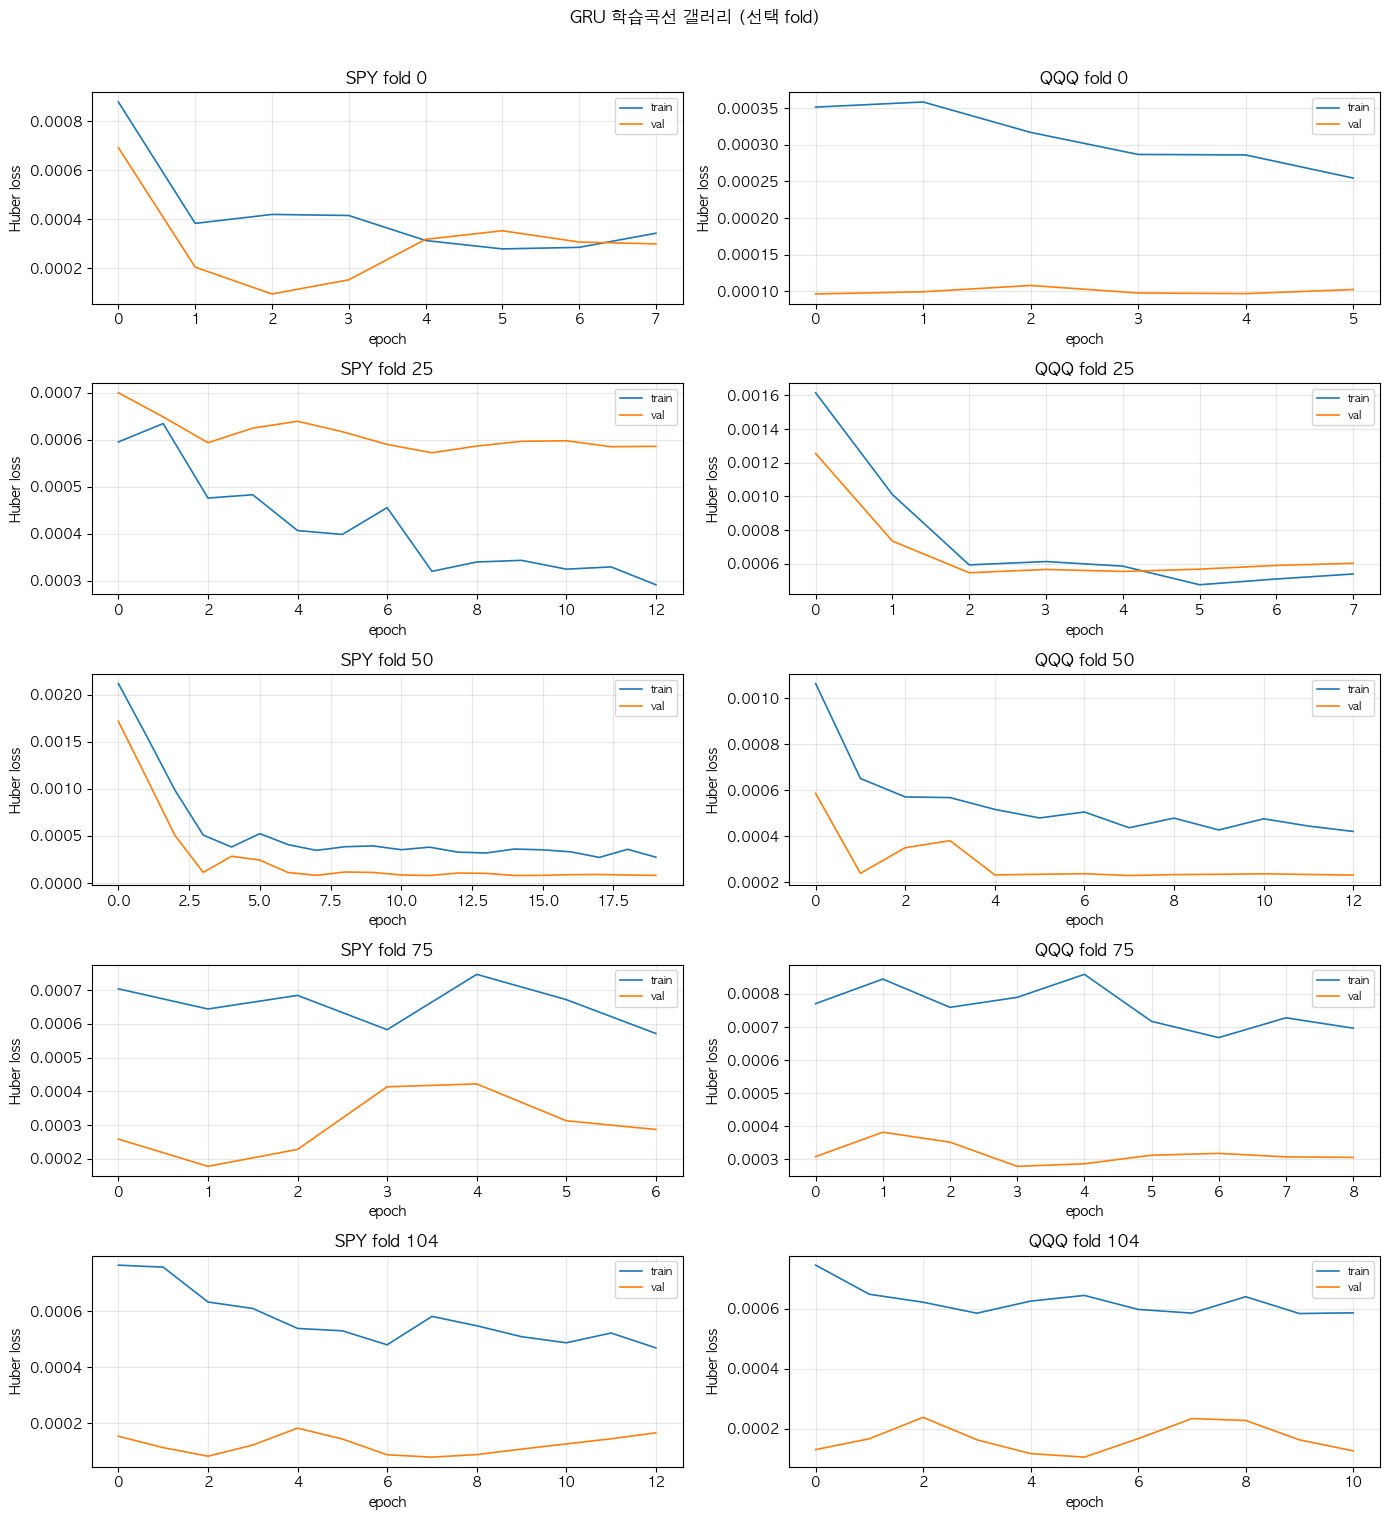

In [13]:
# §9.A — 학습곡선 갤러리 (선택 fold)
sample_folds_idx = [0, 25, 50, 75, len(ALL_RESULTS['SPY']) - 1]

fig, axes = plt.subplots(len(sample_folds_idx), 2, figsize=(14, 3 * len(sample_folds_idx)))
for row, fold_i in enumerate(sample_folds_idx):
    for col, ticker in enumerate(['SPY', 'QQQ']):
        ax = axes[row, col]
        if fold_i < len(ALL_RESULTS[ticker]):
            hist = ALL_RESULTS[ticker][fold_i]['history']
            ax.plot(hist['train_loss'], label='train', lw=1.2)
            ax.plot(hist['val_loss'],   label='val',   lw=1.2)
            ax.set_title(f'{ticker} fold {fold_i}')
            ax.set_xlabel('epoch'); ax.set_ylabel('Huber loss')
            ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('GRU 학습곡선 갤러리 (선택 fold)', y=1.01)
fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'learning_curve_gallery.png', dpi=100)
plt.show()

## §9.B. best_epoch 분포 — 학습 진행도 진단

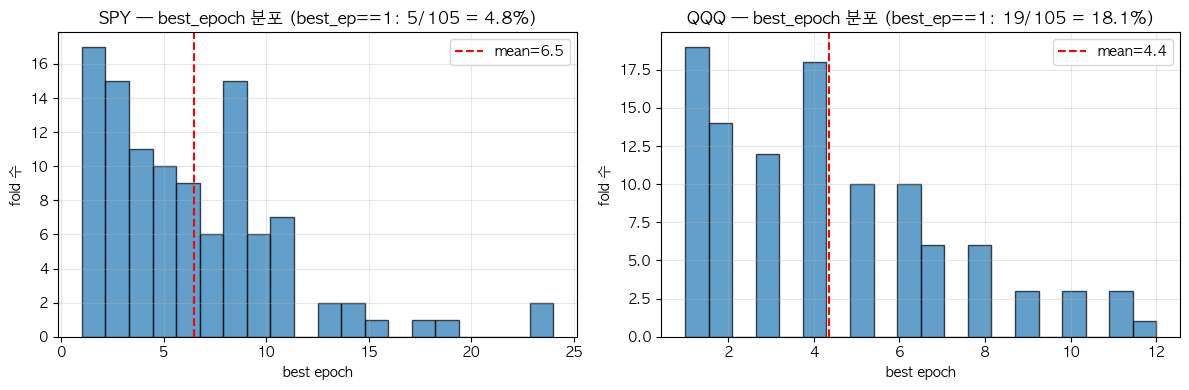

In [14]:
# §9.B — best_epoch 분포 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ticker in zip(axes, ['SPY', 'QQQ']):
    best_eps = [fd['best_epoch'] for fd in ALL_RESULTS[ticker]]
    ax.hist(best_eps, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(best_eps), color='red', ls='--', label=f'mean={np.mean(best_eps):.1f}')
    ax.set_title(f'{ticker} — best_epoch 분포')
    ax.set_xlabel('best epoch'); ax.set_ylabel('fold 수')
    n_early = sum(1 for e in best_eps if e == 1)
    ax.set_title(f'{ticker} — best_epoch 분포 (best_ep==1: {n_early}/{len(best_eps)} = {n_early/len(best_eps):.1%})')
    ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'best_epoch_histogram.png', dpi=100)
plt.show()

## §9.C. 예측 분포 sanity — mean-prediction collapse 검출

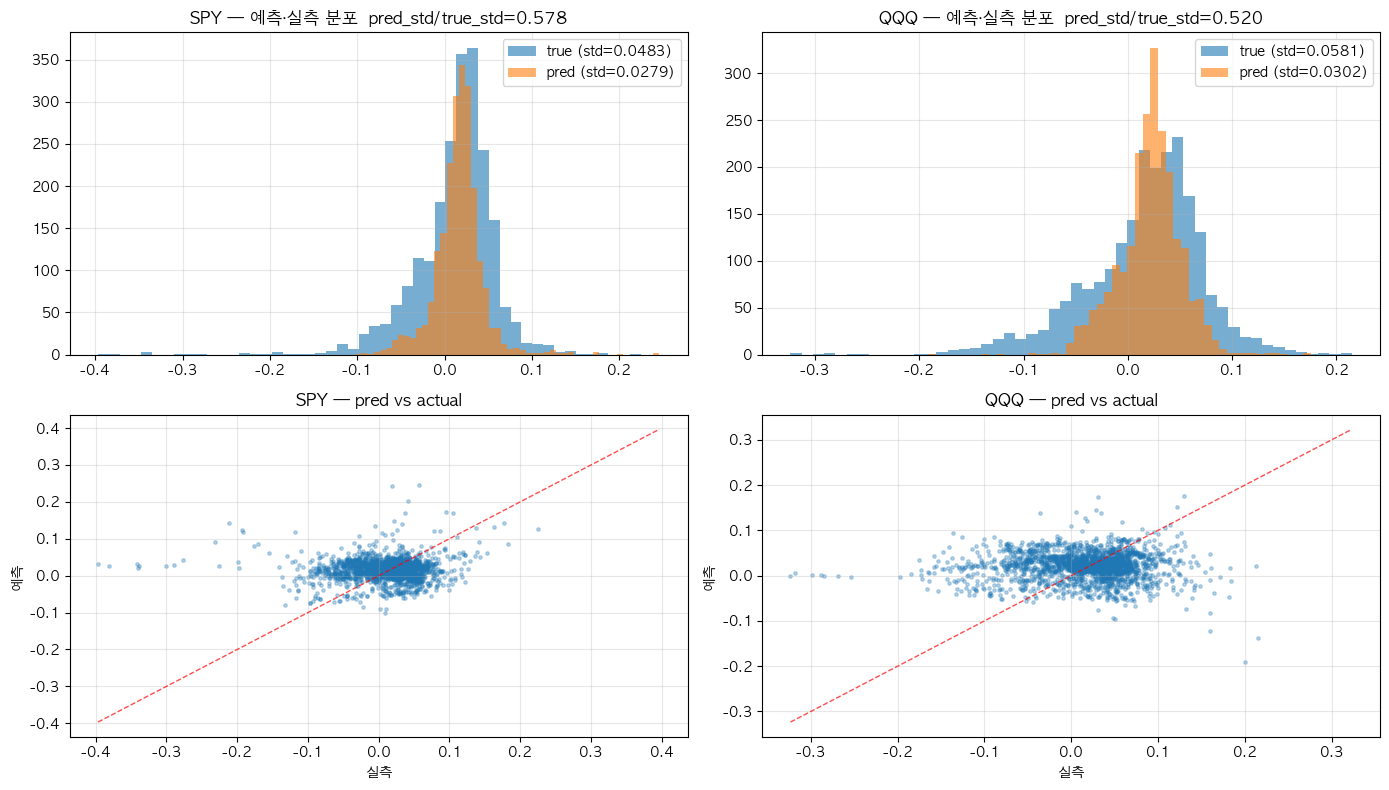

In [15]:
# §9.C — 예측 분포 sanity
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, ticker in enumerate(['SPY', 'QQQ']):
    y_true_all = np.concatenate([fd['y_true'] for fd in ALL_RESULTS[ticker]])
    y_pred_all = np.concatenate([fd['y_pred'] for fd in ALL_RESULTS[ticker]])
    ratio = y_pred_all.std() / (y_true_all.std() + 1e-8)
    collapse = ratio < 0.5

    axes[0, col].hist(y_true_all, bins=50, alpha=0.6, label=f'true (std={y_true_all.std():.4f})')
    axes[0, col].hist(y_pred_all, bins=50, alpha=0.6, label=f'pred (std={y_pred_all.std():.4f})')
    axes[0, col].set_title(f'{ticker} — 예측·실측 분포  pred_std/true_std={ratio:.3f}'
                            + ('  ⚠️collapse' if collapse else ''))
    axes[0, col].legend(); axes[0, col].grid(alpha=0.3)

    axes[1, col].scatter(y_true_all, y_pred_all, s=6, alpha=0.3)
    lim = float(max(abs(y_true_all).max(), abs(y_pred_all).max()))
    axes[1, col].plot([-lim, lim], [-lim, lim], 'r--', lw=1, alpha=0.7)
    axes[1, col].set_title(f'{ticker} — pred vs actual')
    axes[1, col].set_xlabel('실측'); axes[1, col].set_ylabel('예측')
    axes[1, col].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'prediction_distribution.png', dpi=100)
plt.show()

## §9.D. 잔차 시계열 + 부호 혼동행렬

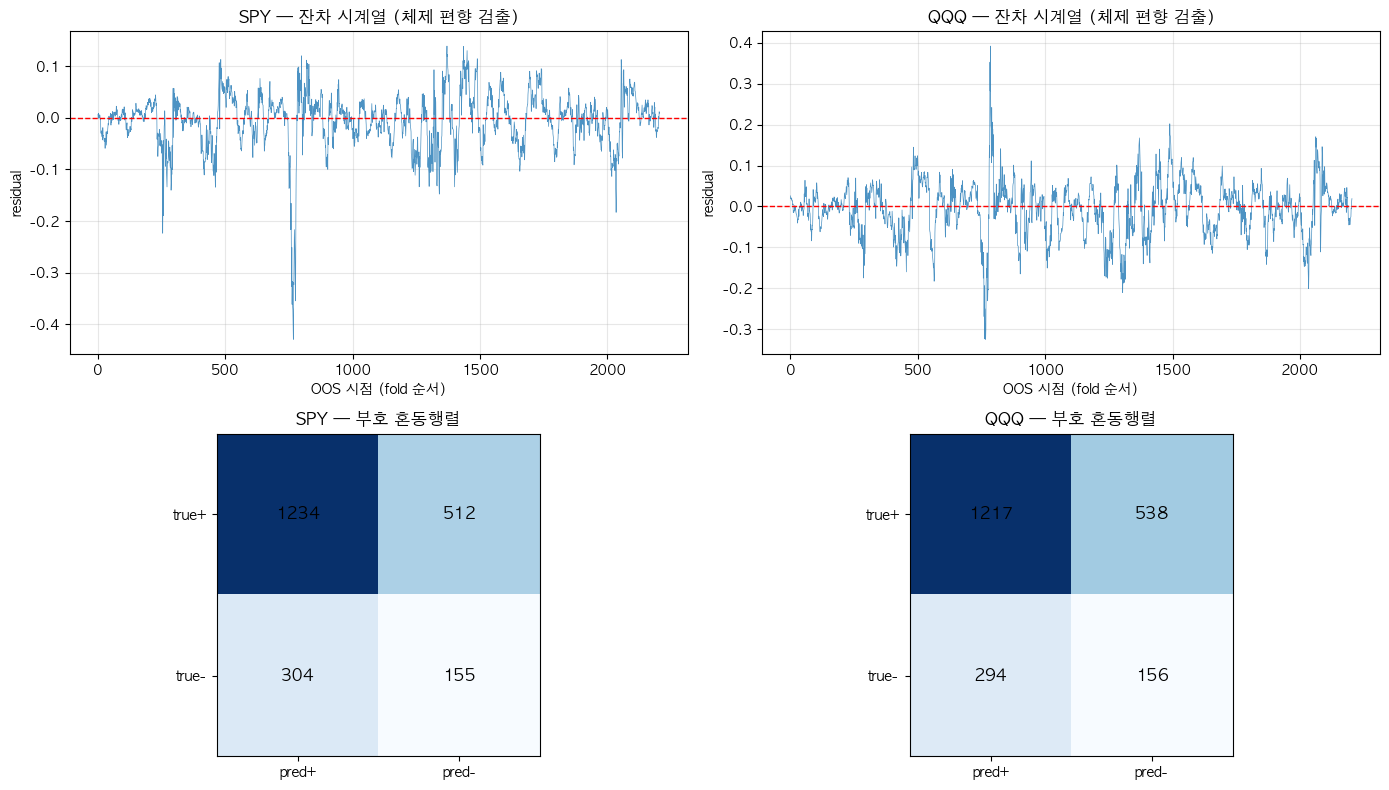

In [16]:
# §9.D — 잔차 시계열 + 부호 혼동행렬
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, ticker in enumerate(['SPY', 'QQQ']):
    y_true_all = np.concatenate([fd['y_true'] for fd in ALL_RESULTS[ticker]])
    y_pred_all = np.concatenate([fd['y_pred'] for fd in ALL_RESULTS[ticker]])
    residuals  = y_true_all - y_pred_all

    axes[0, col].plot(residuals, lw=0.5, alpha=0.8)
    axes[0, col].axhline(0, color='red', ls='--', lw=1)
    axes[0, col].set_title(f'{ticker} — 잔차 시계열 (체제 편향 검출)')
    axes[0, col].set_xlabel('OOS 시점 (fold 순서)'); axes[0, col].set_ylabel('residual')
    axes[0, col].grid(alpha=0.3)

    # 부호 혼동행렬
    tp = ((y_true_all > 0) & (y_pred_all > 0)).sum()
    tn = ((y_true_all < 0) & (y_pred_all < 0)).sum()
    fp = ((y_true_all < 0) & (y_pred_all > 0)).sum()
    fn = ((y_true_all > 0) & (y_pred_all < 0)).sum()
    cm = np.array([[tp, fp], [fn, tn]])
    im = axes[1, col].imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            axes[1, col].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12)
    axes[1, col].set_xticks([0, 1]); axes[1, col].set_yticks([0, 1])
    axes[1, col].set_xticklabels(['pred+', 'pred-'])
    axes[1, col].set_yticklabels(['true+', 'true-'])
    axes[1, col].set_title(f'{ticker} — 부호 혼동행렬')

fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'residual_and_confusion.png', dpi=100)
plt.show()

## §9.E. fold별 R²_OOS / Hit Rate 박스플롯

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_23130/2404417816.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([r2_data['SPY'], r2_data['QQQ']], labels=['SPY', 'QQQ'])
/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_23130/2404417816.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([hit_data['SPY'], hit_data['QQQ']], labels=['SPY', 'QQQ'])


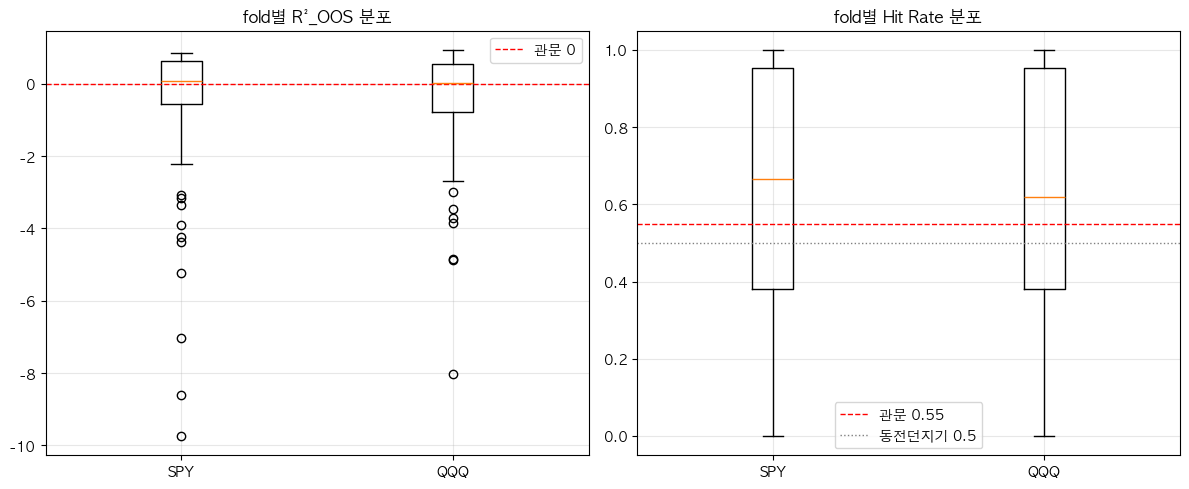

In [17]:
# §9.E — fold별 R²_OOS / Hit Rate 박스플롯
r2_data  = {}
hit_data = {}
for ticker in ['SPY', 'QQQ']:
    fm = compute_fold_metrics(ALL_RESULTS[ticker])
    r2_data[ticker]  = [m['r2_oos']   for m in fm]
    hit_data[ticker] = [m['hit_rate'] for m in fm]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([r2_data['SPY'], r2_data['QQQ']], labels=['SPY', 'QQQ'])
axes[0].axhline(0, color='red', ls='--', lw=1, label='관문 0')
axes[0].set_title('fold별 R²_OOS 분포'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].boxplot([hit_data['SPY'], hit_data['QQQ']], labels=['SPY', 'QQQ'])
axes[1].axhline(0.55, color='red', ls='--', lw=1, label='관문 0.55')
axes[1].axhline(0.5,  color='gray', ls=':',  lw=1, label='동전던지기 0.5')
axes[1].set_title('fold별 Hit Rate 분포'); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'metric_boxplots.png', dpi=100)
plt.show()

## §9.F. Train / Val / Test 동일지표 비교 — 과적합 정량 진단

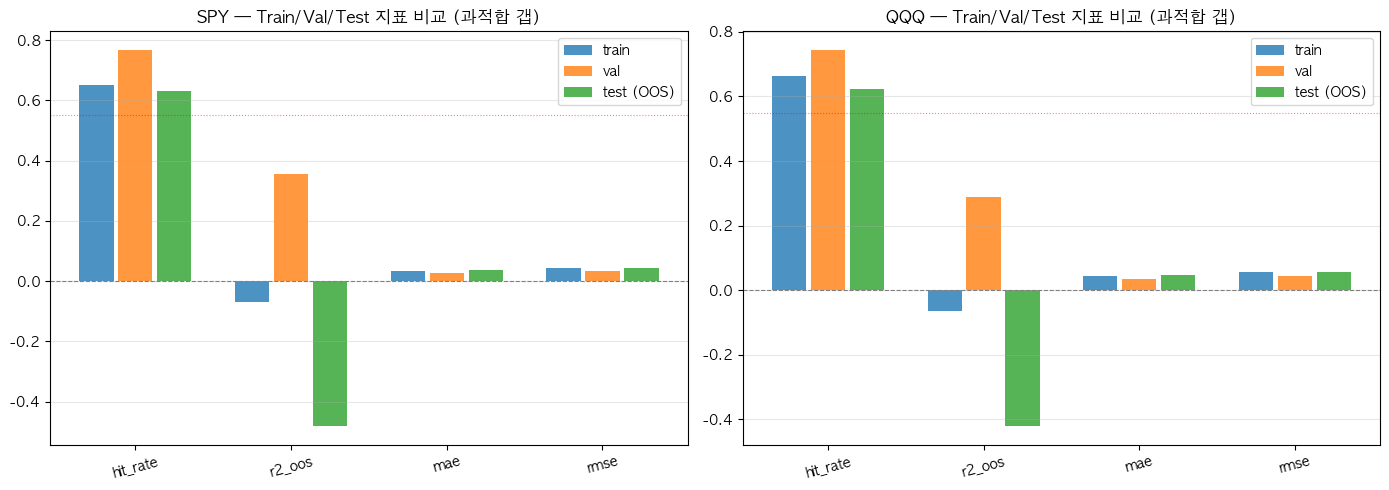


[§9] GRU 평가·시각화 완료. 산출물:
  - /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A/SPY/metrics.json
  - /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A/SPY/fold0_learning_curve.png (§9.A 에서 저장)
  - /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A/QQQ/metrics.json
  - /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A/QQQ/fold0_learning_curve.png (§9.A 에서 저장)
  - /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A/learning_curve_gallery.png
  - /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A/best_epoch_histogram.png
  - /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/시계열_Test/Phase1_GRU/results/setting_A/prediction_di

In [18]:
# §9.F — Train/Val/Test 동일지표 비교
def metrics_for_set(fold_results, set_name):
    """fold 별 (y_true_{set}, y_pred_{set}) 에 대해 메트릭 계산 후 mean 반환."""
    vals = []
    for fd in fold_results:
        yt = fd.get(f'y_true_{set_name}', fd.get('y_true'))
        yp = fd.get(f'y_pred_{set_name}', fd.get('y_pred'))
        if yt is None or yp is None or len(yt) == 0:
            continue
        vals.append({
            'hit_rate': hit_rate(yt, yp),
            'r2_oos':   r2_oos(yt, yp),
            'mae':      mae(yt, yp),
            'rmse':     rmse(yt, yp),
        })
    if not vals:
        return {k: float('nan') for k in ['hit_rate', 'r2_oos', 'mae', 'rmse']}
    return {k: np.nanmean([v[k] for v in vals]) for k in vals[0]}


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_list = ['hit_rate', 'r2_oos', 'mae', 'rmse']

for col, ticker in enumerate(['SPY', 'QQQ']):
    fd = ALL_RESULTS[ticker]
    sets = ['train', 'val', 'test']
    set_labels = {'train': 'y_true_train', 'val': 'y_true_val', 'test': 'y_true'}
    m_train = metrics_for_set(fd, 'train')
    m_val   = metrics_for_set(fd, 'val')
    m_test  = metrics_for_set(fd, 'test')

    x = np.arange(len(metrics_list))
    for i, (label, m) in enumerate([('train', m_train), ('val', m_val), ('test (OOS)', m_test)]):
        axes[col].bar(x + i * 0.25, [m[k] for k in metrics_list], width=0.22, label=label, alpha=0.8)
    axes[col].set_xticks(x + 0.25)
    axes[col].set_xticklabels(metrics_list, rotation=15)
    axes[col].axhline(0, color='gray', ls='--', lw=0.8)
    axes[col].axhline(0.55, color='red', ls=':', lw=0.8, alpha=0.5)
    axes[col].set_title(f'{ticker} — Train/Val/Test 지표 비교 (과적합 갭)')
    axes[col].legend(); axes[col].grid(alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(SETTING_A_DIR / 'overfit_gap.png', dpi=100)
plt.show()

print('\n[§9] GRU 평가·시각화 완료. 산출물:')
for ticker in ['SPY', 'QQQ']:
    print(f'  - {SETTING_A_DIR / ticker / "metrics.json"}')
    print(f'  - {SETTING_A_DIR / ticker / "fold0_learning_curve.png"} (§9.A 에서 저장)')
print(f'  - {SETTING_A_DIR / "learning_curve_gallery.png"}')
print(f'  - {SETTING_A_DIR / "best_epoch_histogram.png"}')
print(f'  - {SETTING_A_DIR / "prediction_distribution.png"}')
print(f'  - {SETTING_A_DIR / "residual_and_confusion.png"}')
print(f'  - {SETTING_A_DIR / "metric_boxplots.png"}')
print(f'  - {SETTING_A_DIR / "overfit_gap.png"}')

## §10. 결론·체크포인트

### Phase 1 관문 판정 요약

| 모델 | 티커 | Hit Rate | R²_OOS | 판정 |
|---|---|---|---|---|
| GRU | SPY | (실행 후 기입) | (실행 후 기입) | - |
| GRU | QQQ | (실행 후 기입) | (실행 후 기입) | - |
| LSTM (3차 Run 참조) | SPY | 0.6313 | -0.2118 | FAIL |
| LSTM (3차 Run 참조) | QQQ | 0.5968 | -0.5472 | FAIL |

### 분석 포인트

1. **R²_OOS 비교**: GRU < LSTM 이면 파라미터 감소가 도움이 됨. 반대면 이미 underfitting.
2. **병리적 폴드 비율**: r2_oos < -1 인 폴드 비율이 LSTM(SPY 72/105, QQQ 71/105) 대비 감소했는지.
3. **best_epoch mean**: LSTM 5.18 대비 GRU가 더 높으면 학습 안정성 개선.
4. **mean-collapse**: pred_std/true_std 비율이 0.5 이상인지.

### 다음 단계

- **관문 PASS**: Phase 2 (Black-Litterman 통합) 진행
- **관문 FAIL + GRU > LSTM**: GRU 방향성 유지, Walk-Forward IS 확대 또는 피처 추가 검토
- **관문 FAIL + GRU ≤ LSTM**: 모델 교체보다 피처 공학이 근본 해결책임을 재확인